Libraries Imported Successfully

Running Device:
cpu

Image Transformation Created


100%|█████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:01<00:00, 5.91MB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 139kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.18MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<?, ?B/s]



Dataset Download Completed

Original Dataset Information
--------------------------------
Training Images: 60000
Testing Images: 10000

CPU Friendly Dataset Created
--------------------------------
Training Samples: 3000
Testing Samples: 500

Classes
--------------------------------
0 : 0
1 : 1
2 : 2
3 : 3
4 : 4
5 : 5
6 : 6
7 : 7
8 : 8
9 : 9

Classes
--------------------------------
0 : 0
1 : 1
2 : 2
3 : 3
4 : 4
5 : 5
6 : 6
7 : 7
8 : 8
9 : 9

Single Image Information
--------------------------------
Image Shape: torch.Size([1, 28, 28])
Label: 9
Class: 9


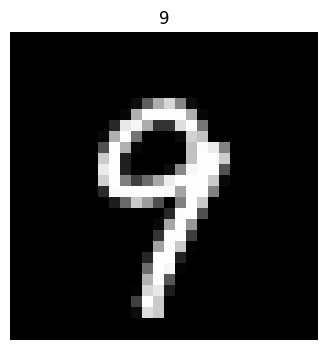

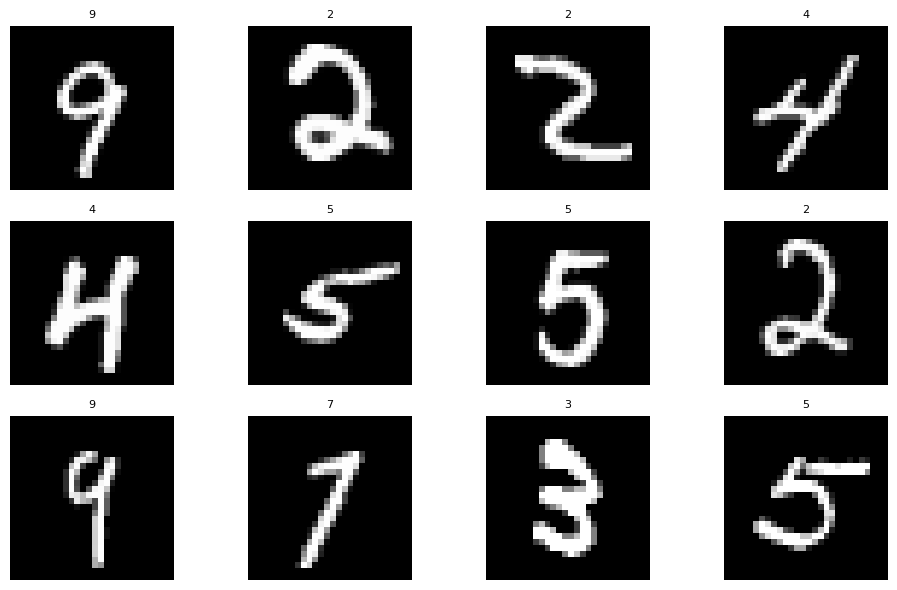


Class Distribution
--------------------------------


,Class_ID,Count,Class_Name
0,9,299,9
1,2,332,2
2,4,266,4
3,5,270,5
4,7,311,7
5,3,297,3
6,8,277,8
7,6,295,6
8,0,306,0
9,1,347,1


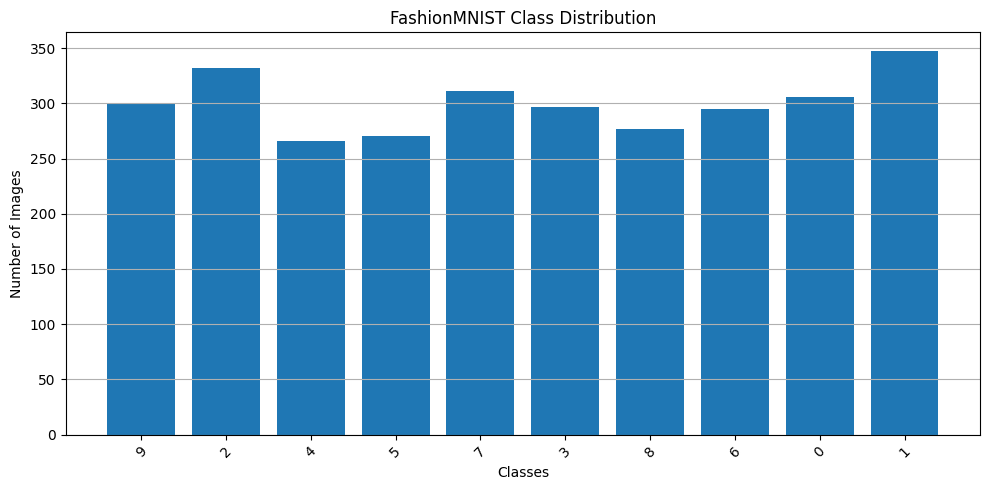


Pixel Information
--------------------------------
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0

Approximate Dataset Memory
--------------------------------
9187.5 KB

PART-1 COMPLETED SUCCESSFULLY

Created Variables:

✔ train_dataset
✔ test_dataset
✔ class_names
✔ transform
✔ device

Dataset Details
--------------------------------
Train Samples: 3000
Test Samples: 500
Image Shape: torch.Size([1, 28, 28])

READY FOR PART-2
IMAGE PREPROCESSING & PATCH CREATION


In [2]:
# ============================================================
# PART-1 : DATASET LOADING & EDA
# PROJECT : VISION TRANSFORMER FOR IMAGE CLASSIFICATION
# FRAMEWORK : PYTORCH
# DATASET : FASHION MNIST
# ============================================================


# ============================================================
# SECTION 1 : IMPORT REQUIRED LIBRARIES
# ============================================================


import torch

import torchvision

from torchvision import datasets

from torchvision import transforms

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from collections import Counter



print("Libraries Imported Successfully")



# ============================================================
# SECTION 2 : CHECK DEVICE
# ============================================================


# Since your system has slow CPU,
# we automatically select available device.


device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)


print()

print("Running Device:")

print(device)



# ============================================================
# SECTION 3 : DEFINE IMAGE TRANSFORMATION
# ============================================================


# Convert PIL image into Tensor.
#
# Pixel values:
#
# Before:
# 0 - 255
#
# After:
# 0 - 1


transform = transforms.Compose(

    [

        transforms.ToTensor()

    ]

)


print()

print("Image Transformation Created")



# ============================================================
# SECTION 4 : DOWNLOAD FASHION MNIST DATASET
# ============================================================


# torchvision automatically downloads
# FashionMNIST if it is not available.
#
# After first download:
# it will reuse the local copy.


train_full_dataset = datasets.MNIST(

    root="data",

    train=True,

    download=True,

    transform=transform

)



test_full_dataset = datasets.MNIST(

    root="data",

    train=False,

    download=True,

    transform=transform

)



print()

print("Dataset Download Completed")



# ============================================================
# SECTION 5 : DISPLAY ORIGINAL DATASET SIZE
# ============================================================


print()

print("Original Dataset Information")

print("--------------------------------")


print(

    "Training Images:",

    len(train_full_dataset)

)


print(

    "Testing Images:",

    len(test_full_dataset)

)



# ============================================================
# SECTION 6 : CREATE CPU FRIENDLY SUBSET
# ============================================================


# Full dataset is large for your machine.
#
# We only select a small subset.


TRAIN_SIZE = 3000

TEST_SIZE = 500



train_dataset, _ = torch.utils.data.random_split(

    train_full_dataset,

    [

        TRAIN_SIZE,

        len(train_full_dataset)-TRAIN_SIZE

    ]

)



test_dataset, _ = torch.utils.data.random_split(

    test_full_dataset,

    [

        TEST_SIZE,

        len(test_full_dataset)-TEST_SIZE

    ]

)



print()

print("CPU Friendly Dataset Created")

print("--------------------------------")


print(

    "Training Samples:",

    len(train_dataset)

)


print(

    "Testing Samples:",

    len(test_dataset)

)



# ============================================================
# SECTION 7 : DEFINE CLASS NAMES
# ============================================================


class_names = [

    "0",

    "1",

    "2",

    "3",

    "4",

    "5",

    "6",

    "7",

    "8",

    "9"

]


print()

print("Classes")

print("--------------------------------")


for index, name in enumerate(class_names):

    print(

        index,

        ":",

        name

    )


print()

print("Classes")

print("--------------------------------")


for index, name in enumerate(class_names):

    print(

        index,

        ":",

        name

    )



# ============================================================
# SECTION 8 : CHECK SINGLE IMAGE
# ============================================================


image, label = train_dataset[0]



print()

print("Single Image Information")

print("--------------------------------")


print(

    "Image Shape:",

    image.shape

)


print(

    "Label:",

    label

)


print(

    "Class:",

    class_names[label]

)



# ============================================================
# SECTION 9 : VISUALIZE SINGLE IMAGE
# ============================================================



plt.figure(

    figsize=(4,4)

)


plt.imshow(

    image.squeeze(),

    cmap="gray"

)


plt.title(

    class_names[label]

)


plt.axis(

    "off"

)


plt.show()



# ============================================================
# SECTION 10 : DISPLAY MULTIPLE IMAGES
# ============================================================


plt.figure(

    figsize=(10,6)

)



for i in range(12):


    image, label = train_dataset[i]


    plt.subplot(

        3,

        4,

        i+1

    )


    plt.imshow(

        image.squeeze(),

        cmap="gray"

    )


    plt.title(

        class_names[label],

        fontsize=8

    )


    plt.axis(

        "off"

    )



plt.tight_layout()


plt.show()



# ============================================================
# SECTION 11 : DATASET LABEL ANALYSIS
# ============================================================



labels = []


for _, label in train_dataset:


    labels.append(label)



label_count = Counter(labels)



class_distribution = pd.DataFrame(

    {

        "Class_ID": list(label_count.keys()),

        "Count": list(label_count.values())

    }

)



class_distribution["Class_Name"] = (

    class_distribution["Class_ID"]

    .apply(

        lambda x: class_names[x]

    )

)



print()

print("Class Distribution")

print("--------------------------------")


display(

    class_distribution

)



# ============================================================
# SECTION 12 : VISUALIZE CLASS DISTRIBUTION
# ============================================================


plt.figure(

    figsize=(10,5)

)



plt.bar(

    class_distribution["Class_Name"],

    class_distribution["Count"]

)



plt.xticks(

    rotation=45

)


plt.title(

    "FashionMNIST Class Distribution"

)


plt.xlabel(

    "Classes"

)


plt.ylabel(

    "Number of Images"

)



plt.grid(

    axis="y"

)


plt.tight_layout()


plt.show()



# ============================================================
# SECTION 13 : PIXEL VALUE ANALYSIS
# ============================================================



sample_image, _ = train_dataset[0]



print()

print("Pixel Information")

print("--------------------------------")


print(

    "Minimum Pixel Value:",

    sample_image.min().item()

)


print(

    "Maximum Pixel Value:",

    sample_image.max().item()

)



# ============================================================
# SECTION 14 : DATASET MEMORY ESTIMATION
# ============================================================


image_size = (

    28 *

    28

)


total_pixels = (

    TRAIN_SIZE *

    image_size

)



memory_kb = (

    total_pixels *

    4 /

    1024

)



print()

print("Approximate Dataset Memory")

print("--------------------------------")


print(

    round(memory_kb,2),

    "KB"

)



# ============================================================
# SECTION 15 : SAVE IMPORTANT VARIABLES
# ============================================================



print()

print("="*60)

print("PART-1 COMPLETED SUCCESSFULLY")

print("="*60)



print()

print("Created Variables:")

print()

print("✔ train_dataset")

print("✔ test_dataset")

print("✔ class_names")

print("✔ transform")

print("✔ device")



print()

print("Dataset Details")

print("--------------------------------")

print(

    "Train Samples:",

    len(train_dataset)

)


print(

    "Test Samples:",

    len(test_dataset)

)


print(

    "Image Shape:",

    image.shape

)


print()

print("READY FOR PART-2")

print("IMAGE PREPROCESSING & PATCH CREATION")

Part-2 Libraries Imported Successfully

DataLoaders Created

Training Batches: 188
Testing Batches: 32

Original Image Information
--------------------------------
Image Shape: torch.Size([1, 28, 28])
Label: 9

Patch Configuration
--------------------------------
Image Size: 28 x 28
Patch Size: 7 x 7
Total Patches: 16

Patch Creation Completed
--------------------------------
Number of Patches: 16
Single Patch Shape: torch.Size([1, 7, 7])


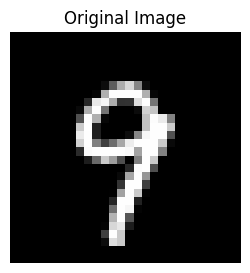

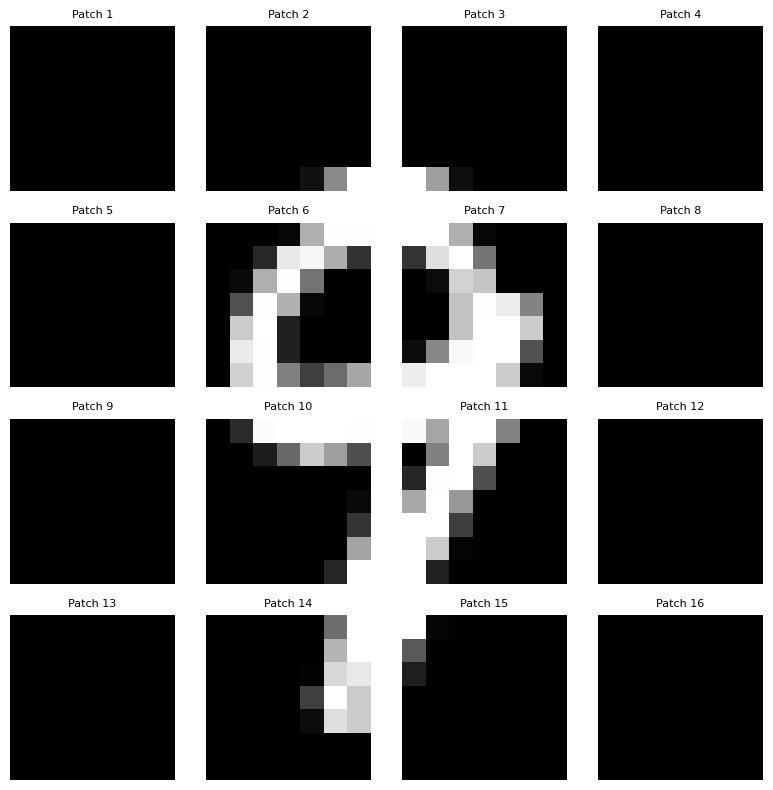


Flattened Patch Information
--------------------------------
Flattened Patch Shape: torch.Size([16, 49])

Patch Embedding Layer Created

Linear(in_features=49, out_features=64, bias=True)

Patch Token Information
--------------------------------
Patch Tokens Shape: torch.Size([16, 64])

Class Token Shape
torch.Size([1, 1, 64])

After Batch Dimension
torch.Size([1, 16, 64])

Vision Transformer Input
--------------------------------
ViT Input Shape: torch.Size([1, 17, 64])

After Positional Embedding
torch.Size([1, 17, 64])

PART-2 COMPLETED SUCCESSFULLY

Created Variables

✔ train_loader
✔ test_loader
✔ NUM_PATCHES
✔ PATCH_SIZE
✔ patch_embedding
✔ patch_tokens
✔ class_token
✔ position_embedding
✔ vit_input

READY FOR PART-3
VISION TRANSFORMER ARCHITECTURE & TRAINING


In [3]:
# ============================================================
# PART-2 : IMAGE PREPROCESSING & PATCH CREATION
# PROJECT : VISION TRANSFORMER FOR IMAGE CLASSIFICATION
# FRAMEWORK : PYTORCH
# ============================================================



# ============================================================
# SECTION 1 : IMPORT REQUIRED LIBRARIES
# ============================================================


import torch

from torch.utils.data import DataLoader

import torch.nn as nn

import matplotlib.pyplot as plt



print("Part-2 Libraries Imported Successfully")



# ============================================================
# SECTION 2 : CREATE DATALOADERS
# ============================================================


# Small batch size because CPU is slow.

BATCH_SIZE = 16



train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0

)



test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0

)



print()

print("DataLoaders Created")

print()

print("Training Batches:", len(train_loader))

print("Testing Batches:", len(test_loader))



# ============================================================
# SECTION 3 : GET ONE IMAGE SAMPLE
# ============================================================


image, label = train_dataset[0]



print()

print("Original Image Information")

print("--------------------------------")


print(

    "Image Shape:",

    image.shape

)


print(

    "Label:",

    label

)



# ============================================================
# SECTION 4 : DEFINE PATCH PARAMETERS
# ============================================================


IMAGE_SIZE = 28


PATCH_SIZE = 7



# Number of patches calculation.

NUM_PATCHES = (

    IMAGE_SIZE // PATCH_SIZE

) ** 2



print()

print("Patch Configuration")

print("--------------------------------")


print(

    "Image Size:",

    IMAGE_SIZE,

    "x",

    IMAGE_SIZE

)


print(

    "Patch Size:",

    PATCH_SIZE,

    "x",

    PATCH_SIZE

)


print(

    "Total Patches:",

    NUM_PATCHES

)



# ============================================================
# SECTION 5 : CREATE PATCH EXTRACTION FUNCTION
# ============================================================



def image_to_patches(

    image,

    patch_size

):


    """
    Converts image into patches.

    Input:
    Image shape:
    (Channels, Height, Width)


    Output:
    Number of patches,
    Patch pixels
    """



    channels, height, width = image.shape



    patches = image.unfold(

        1,

        patch_size,

        patch_size

    ).unfold(

        2,

        patch_size,

        patch_size

    )



    # Current shape:

    # Channels,
    # Number of rows,
    # Number of columns,
    # Patch Height,
    # Patch Width



    patches = patches.permute(

        1,

        2,

        0,

        3,

        4

    )



    # Combine rows and columns.

    patches = patches.reshape(

        -1,

        channels,

        patch_size,

        patch_size

    )



    return patches



# ============================================================
# SECTION 6 : CREATE PATCHES FROM SAMPLE IMAGE
# ============================================================



patches = image_to_patches(

    image,

    PATCH_SIZE

)



print()

print("Patch Creation Completed")

print("--------------------------------")


print(

    "Number of Patches:",

    patches.shape[0]

)


print(

    "Single Patch Shape:",

    patches[0].shape

)



# ============================================================
# SECTION 7 : VISUALIZE ORIGINAL IMAGE
# ============================================================



plt.figure(

    figsize=(3,3)

)



plt.imshow(

    image.squeeze(),

    cmap="gray"

)


plt.title(

    "Original Image"

)


plt.axis(

    "off"

)


plt.show()



# ============================================================
# SECTION 8 : VISUALIZE IMAGE PATCHES
# ============================================================



plt.figure(

    figsize=(8,8)

)



for index in range(NUM_PATCHES):


    plt.subplot(

        4,

        4,

        index+1

    )


    plt.imshow(

        patches[index].squeeze(),

        cmap="gray"

    )


    plt.title(

        f"Patch {index+1}",

        fontsize=8

    )


    plt.axis(

        "off"

    )



plt.tight_layout()


plt.show()



# ============================================================
# SECTION 9 : FLATTEN PATCHES
# ============================================================


# Transformer expects tokens.
#
# Each patch becomes a vector.


flattened_patches = patches.flatten(

    start_dim=1

)



print()

print("Flattened Patch Information")

print("--------------------------------")


print(

    "Flattened Patch Shape:",

    flattened_patches.shape

)



# Explanation:
#
# Patch:
#
# 1 channel × 7 × 7
#
# becomes:
#
# 49 values



# ============================================================
# SECTION 10 : CREATE PATCH EMBEDDING LAYER
# ============================================================


# Similar to word embedding in NLP.
#
# Converts patch vectors into embeddings.


EMBEDDING_DIM = 64



patch_embedding = nn.Linear(

    PATCH_SIZE * PATCH_SIZE,

    EMBEDDING_DIM

)



print()

print("Patch Embedding Layer Created")

print()

print(

    patch_embedding

)



# ============================================================
# SECTION 11 : GENERATE PATCH TOKENS
# ============================================================



patch_tokens = patch_embedding(

    flattened_patches

)



print()

print("Patch Token Information")

print("--------------------------------")


print(

    "Patch Tokens Shape:",

    patch_tokens.shape

)



# Expected:

# 16 patches × 64 embedding



# ============================================================
# SECTION 12 : CREATE CLASS TOKEN
# ============================================================


# ViT uses a special CLS token
# similar to BERT.


class_token = nn.Parameter(

    torch.randn(

        1,

        1,

        EMBEDDING_DIM

    )

)



print()

print("Class Token Shape")

print(

    class_token.shape

)



# ============================================================
# SECTION 13 : ADD BATCH DIMENSION
# ============================================================



patch_tokens = patch_tokens.unsqueeze(

    0

)



print()

print("After Batch Dimension")

print(

    patch_tokens.shape

)



# ============================================================
# SECTION 14 : ADD CLASS TOKEN TO PATCH TOKENS
# ============================================================



batch_class_token = class_token.expand(

    patch_tokens.shape[0],

    -1,

    -1

)



vit_input = torch.cat(

    [

        batch_class_token,

        patch_tokens

    ],

    dim=1

)



print()

print("Vision Transformer Input")

print("--------------------------------")


print(

    "ViT Input Shape:",

    vit_input.shape

)



# Expected:

# Batch Size,
# 17 tokens,
# 64 embedding



# ============================================================
# SECTION 15 : POSITION EMBEDDINGS
# ============================================================


# Transformer has no understanding
# of token positions.
#
# So we add positional embeddings.


NUM_TOKENS = NUM_PATCHES + 1



position_embedding = nn.Parameter(

    torch.randn(

        1,

        NUM_TOKENS,

        EMBEDDING_DIM

    )

)



vit_input = vit_input + position_embedding



print()

print("After Positional Embedding")

print(

    vit_input.shape

)



# ============================================================
# SECTION 16 : SAVE IMPORTANT VARIABLES
# ============================================================



print()

print("="*60)

print("PART-2 COMPLETED SUCCESSFULLY")

print("="*60)


print()

print("Created Variables")

print()

print("✔ train_loader")

print("✔ test_loader")

print("✔ NUM_PATCHES")

print("✔ PATCH_SIZE")

print("✔ patch_embedding")

print("✔ patch_tokens")

print("✔ class_token")

print("✔ position_embedding")

print("✔ vit_input")



print()

print("READY FOR PART-3")

print("VISION TRANSFORMER ARCHITECTURE & TRAINING")


Part-3 Libraries Imported Successfully

Vision Transformer Configuration
--------------------------------
Number of Patches: 16
Embedding Dimension: 64
Attention Heads: 4
Transformer Layers: 2
Classes: 10
Epochs: 10

Vision Transformer Class Created Successfully

Model Created Successfully
VisionTransformer(
  (patch_embedding): PatchEmbedding(
    (projection): Linear(in_features=49, out_features=64, bias=True)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, e

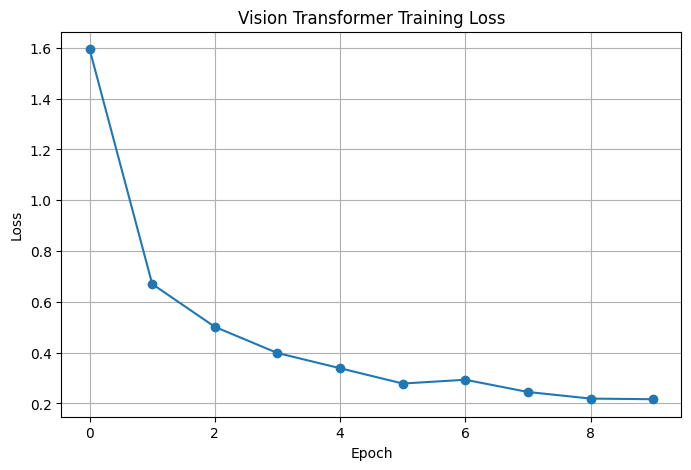


Model Saved Successfully
vision_transformer_mnist.pth

PART-3 COMPLETED SUCCESSFULLY

Created Components:

✔ Patch Embedding
✔ Class Token
✔ Positional Embedding
✔ Transformer Encoder
✔ CLS Token Classification
✔ Training Pipeline
✔ Model Saving

READY FOR PART-4
MODEL EVALUATION & PREDICTION


In [4]:
# ============================================================
# PART-3 : BUILD VISION TRANSFORMER & TRAINING
# PROJECT : VISION TRANSFORMER FOR IMAGE CLASSIFICATION
# FRAMEWORK : PYTORCH
# ============================================================



# ============================================================
# SECTION 1 : IMPORT REQUIRED LIBRARIES
# ============================================================


import torch

import torch.nn as nn

import torch.optim as optim

import matplotlib.pyplot as plt



print("Part-3 Libraries Imported Successfully")



# ============================================================
# SECTION 2 : DEFINE MODEL PARAMETERS
# ============================================================


IMAGE_SIZE = 28

PATCH_SIZE = 7

NUM_PATCHES = (

    IMAGE_SIZE // PATCH_SIZE

) ** 2


EMBEDDING_DIM = 64

NUM_HEADS = 4

NUM_ENCODER_LAYERS = 2

NUM_CLASSES = 10

DROPOUT = 0.1

EPOCHS = 10



print()

print("Vision Transformer Configuration")

print("--------------------------------")

print("Number of Patches:", NUM_PATCHES)

print("Embedding Dimension:", EMBEDDING_DIM)

print("Attention Heads:", NUM_HEADS)

print("Transformer Layers:", NUM_ENCODER_LAYERS)

print("Classes:", NUM_CLASSES)

print("Epochs:", EPOCHS)



# ============================================================
# SECTION 3 : CREATE PATCH EMBEDDING MODULE
# ============================================================


class PatchEmbedding(nn.Module):


    def __init__(self):

        super().__init__()


        self.patch_size = PATCH_SIZE


        self.projection = nn.Linear(

            PATCH_SIZE * PATCH_SIZE,

            EMBEDDING_DIM

        )


    def forward(self, x):


        batch_size = x.shape[0]


        # Create patches

        patches = x.unfold(

            2,

            PATCH_SIZE,

            PATCH_SIZE

        ).unfold(

            3,

            PATCH_SIZE,

            PATCH_SIZE

        )


        # Rearrange patches

        patches = patches.permute(

            0,

            2,

            3,

            1,

            4,

            5

        )


        # Flatten patches

        patches = patches.reshape(

            batch_size,

            NUM_PATCHES,

            -1

        )


        # Convert patches into embeddings

        embeddings = self.projection(

            patches

        )


        return embeddings



# ============================================================
# SECTION 4 : CREATE VISION TRANSFORMER MODEL
# ============================================================



class VisionTransformer(nn.Module):


    def __init__(self):

        super().__init__()



        # Patch embedding layer

        self.patch_embedding = PatchEmbedding()



        # Learnable class token

        self.class_token = nn.Parameter(

            torch.randn(

                1,

                1,

                EMBEDDING_DIM

            )

        )



        # Positional embedding

        self.position_embedding = nn.Parameter(

            torch.randn(

                1,

                NUM_PATCHES + 1,

                EMBEDDING_DIM

            )

        )



        # Transformer encoder

        encoder_layer = nn.TransformerEncoderLayer(

            d_model=EMBEDDING_DIM,

            nhead=NUM_HEADS,

            dim_feedforward=256,

            dropout=DROPOUT,

            batch_first=True

        )



        self.transformer_encoder = nn.TransformerEncoder(

            encoder_layer,

            num_layers=NUM_ENCODER_LAYERS

        )



        # Classification head

        self.classifier = nn.Sequential(

            nn.LayerNorm(

                EMBEDDING_DIM

            ),

            nn.Linear(

                EMBEDDING_DIM,

                NUM_CLASSES

            )

        )



    def forward(self, x):


        batch_size = x.shape[0]


        # Convert images to patch embeddings

        x = self.patch_embedding(

            x

        )



        # Create class tokens for every image

        cls_tokens = self.class_token.expand(

            batch_size,

            -1,

            -1

        )



        # Add class token

        x = torch.cat(

            (

                cls_tokens,

                x

            ),

            dim=1

        )



        # Add positional embeddings

        x = x + self.position_embedding



        # Transformer processing

        x = self.transformer_encoder(

            x

        )



        # Take CLS token output

        cls_output = x[:,0]



        # Classification

        output = self.classifier(

            cls_output

        )


        return output



print()

print("Vision Transformer Class Created Successfully")



# ============================================================
# SECTION 5 : CREATE MODEL
# ============================================================



model = VisionTransformer()



model = model.to(

    device

)



print()

print("Model Created Successfully")

print(model)



# ============================================================
# SECTION 6 : COUNT PARAMETERS
# ============================================================



total_parameters = sum(

    p.numel()

    for p in model.parameters()

)



print()

print("Total Trainable Parameters:")

print(total_parameters)



# ============================================================
# SECTION 7 : DEFINE LOSS AND OPTIMIZER
# ============================================================



criterion = nn.CrossEntropyLoss()



optimizer = optim.Adam(

    model.parameters(),

    lr=0.001

)



# ============================================================
# SECTION 8 : TRAINING LOOP
# ============================================================



train_losses = []



print()

print("="*60)

print("STARTING TRAINING")

print("="*60)



for epoch in range(EPOCHS):


    model.train()


    running_loss = 0


    correct = 0

    total = 0



    for images, labels in train_loader:


        images = images.to(device)

        labels = labels.to(device)



        # Remove previous gradients

        optimizer.zero_grad()



        # Forward pass

        outputs = model(

            images

        )



        # Calculate loss

        loss = criterion(

            outputs,

            labels

        )



        # Backpropagation

        loss.backward()



        # Update weights

        optimizer.step()



        running_loss += loss.item()



        # Accuracy calculation

        predictions = torch.argmax(

            outputs,

            dim=1

        )


        correct += (

            predictions == labels

        ).sum().item()


        total += labels.size(0)



    epoch_loss = (

        running_loss /

        len(train_loader)

    )


    epoch_accuracy = (

        correct /

        total

    ) * 100



    train_losses.append(

        epoch_loss

    )



    print(

        f"Epoch {epoch+1}/{EPOCHS} "

        f"Loss: {epoch_loss:.4f} "

        f"Accuracy: {epoch_accuracy:.2f}%"

    )




# ============================================================
# SECTION 9 : TRAINING LOSS VISUALIZATION
# ============================================================



plt.figure(

    figsize=(8,5)

)


plt.plot(

    train_losses,

    marker="o"

)


plt.title(

    "Vision Transformer Training Loss"

)


plt.xlabel(

    "Epoch"

)


plt.ylabel(

    "Loss"

)


plt.grid()

plt.show()



# ============================================================
# SECTION 10 : SAVE MODEL
# ============================================================



MODEL_PATH = "vision_transformer_mnist.pth"



torch.save(

    model.state_dict(),

    MODEL_PATH

)



print()

print("Model Saved Successfully")

print(MODEL_PATH)



# ============================================================
# SECTION 11 : PART-3 SUMMARY
# ============================================================



print()

print("="*60)

print("PART-3 COMPLETED SUCCESSFULLY")

print("="*60)


print()

print("Created Components:")

print()

print("✔ Patch Embedding")

print("✔ Class Token")

print("✔ Positional Embedding")

print("✔ Transformer Encoder")

print("✔ CLS Token Classification")

print("✔ Training Pipeline")

print("✔ Model Saving")


print()

print("READY FOR PART-4")

print("MODEL EVALUATION & PREDICTION")

Part-4 Libraries Imported Successfully

Trained Vision Transformer Loaded Successfully

Evaluating Model...

MODEL PERFORMANCE

Test Accuracy : 91.40%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.98      0.97      0.98        62
           2       0.93      0.90      0.92        62
           3       0.83      0.92      0.87        49
           4       1.00      0.90      0.95        50
           5       0.79      0.88      0.83        48
           6       0.93      0.97      0.95        39
           7       0.90      0.92      0.91        48
           8       0.94      0.85      0.89        54
           9       0.87      0.89      0.88        46

    accuracy                           0.91       500
   macro avg       0.92      0.92      0.91       500
weighted avg       0.92      0.91      0.91       500



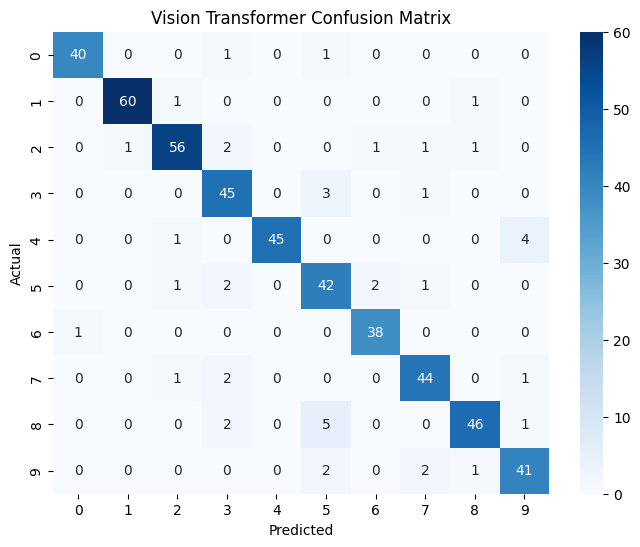


Sample Predictions


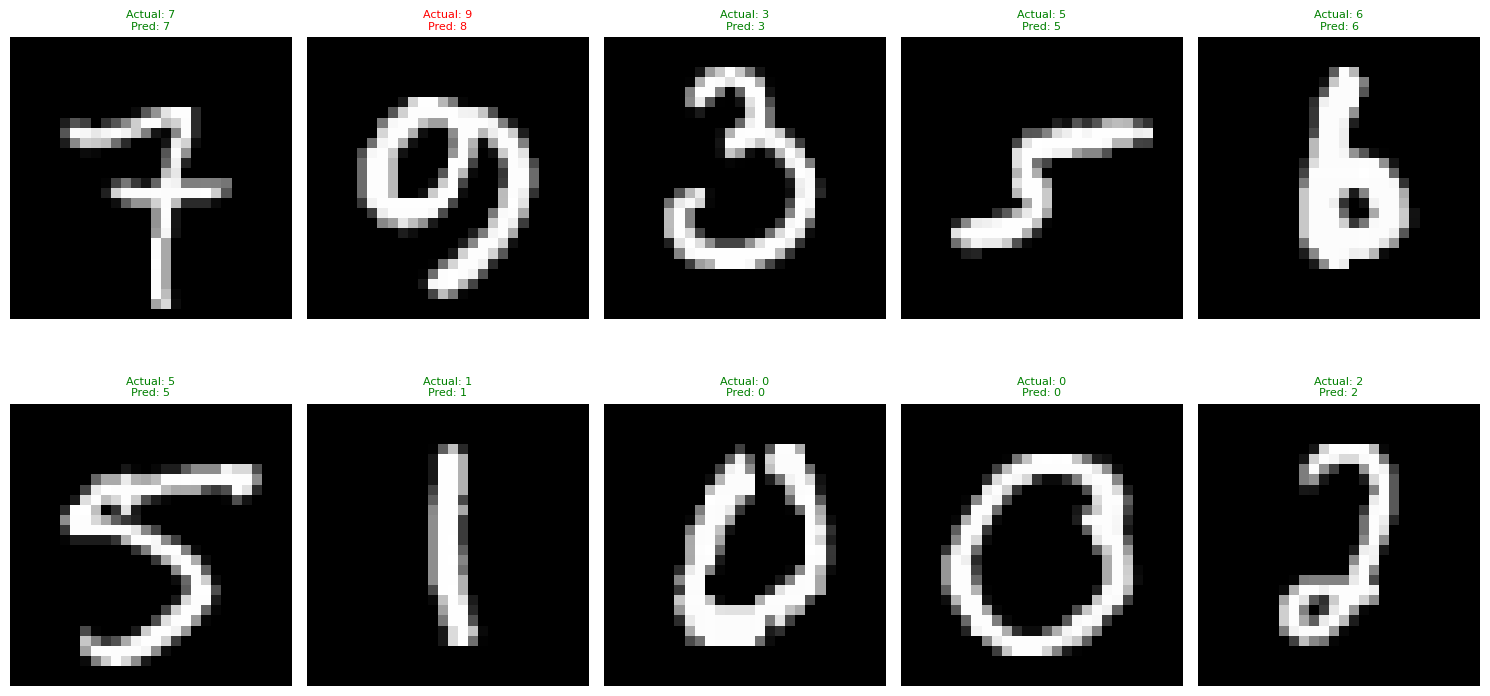

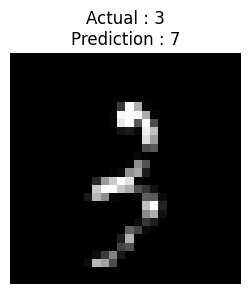


Prediction Result
--------------------------------
Actual Class: 3
Predicted Class: 7

FINAL MODEL INFORMATION
architecture : Vision Transformer
dataset : MNIST
image_size : 28x28
patch_size : 7x7
number_of_patches : 16
embedding_dimension : 64
attention_heads : 4
transformer_layers : 2
accuracy : 91.4

VISION TRANSFORMER PROJECT COMPLETED SUCCESSFULLY

PROJECT PIPELINE

✔ MNIST Dataset Loading
✔ Image Normalization
✔ Image Patch Creation
✔ Patch Embedding
✔ Class Token
✔ Positional Encoding
✔ Transformer Encoder
✔ Classification Head
✔ Model Training
✔ Model Evaluation
✔ Prediction Pipeline

MODEL SAVED:
vision_transformer_mnist.pth

END-TO-END VISION TRANSFORMER IMPLEMENTATION COMPLETE


In [5]:
# ============================================================
# PART-4 : MODEL EVALUATION & PREDICTION
# PROJECT : VISION TRANSFORMER FOR IMAGE CLASSIFICATION
# FRAMEWORK : PYTORCH
# ============================================================



# ============================================================
# SECTION 1 : IMPORT REQUIRED LIBRARIES
# ============================================================


import torch

import matplotlib.pyplot as plt

import numpy as np

from sklearn.metrics import (

    classification_report,

    confusion_matrix,

    accuracy_score

)

import seaborn as sns



print("Part-4 Libraries Imported Successfully")



# ============================================================
# SECTION 2 : LOAD TRAINED MODEL
# ============================================================



# Load saved weights

model.load_state_dict(

    torch.load(

        MODEL_PATH,

        map_location=device

    )

)



# Move model to device

model = model.to(

    device

)



# Evaluation mode

model.eval()



print()

print("Trained Vision Transformer Loaded Successfully")



# ============================================================
# SECTION 3 : MODEL EVALUATION
# ============================================================



all_predictions = []

all_labels = []



correct = 0

total = 0



print()

print("Evaluating Model...")



with torch.no_grad():


    for images, labels in test_loader:


        images = images.to(device)

        labels = labels.to(device)



        # Forward pass

        outputs = model(

            images

        )



        # Get predicted class

        predictions = torch.argmax(

            outputs,

            dim=1

        )



        # Store predictions

        all_predictions.extend(

            predictions.cpu().numpy()

        )


        all_labels.extend(

            labels.cpu().numpy()

        )



        correct += (

            predictions == labels

        ).sum().item()



        total += labels.size(0)



# Calculate accuracy

test_accuracy = (

    correct /

    total

) * 100



print()

print("="*60)

print("MODEL PERFORMANCE")

print("="*60)


print()

print(

    f"Test Accuracy : {test_accuracy:.2f}%"

)



# ============================================================
# SECTION 4 : CLASSIFICATION REPORT
# ============================================================



print()

print("="*60)

print("CLASSIFICATION REPORT")

print("="*60)



print(

    classification_report(

        all_labels,

        all_predictions,

        target_names=class_names

    )

)



# ============================================================
# SECTION 5 : CONFUSION MATRIX
# ============================================================



cm = confusion_matrix(

    all_labels,

    all_predictions

)



plt.figure(

    figsize=(8,6)

)



sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)



plt.xlabel(

    "Predicted"

)



plt.ylabel(

    "Actual"

)



plt.title(

    "Vision Transformer Confusion Matrix"

)



plt.show()



# ============================================================
# SECTION 6 : DISPLAY RANDOM PREDICTIONS
# ============================================================



def display_predictions(

    dataset,

    model,

    number_of_images=10

):


    model.eval()


    plt.figure(

        figsize=(15,8)

    )


    for i in range(number_of_images):


        image, label = dataset[i]


        input_image = image.unsqueeze(

            0

        ).to(device)



        with torch.no_grad():


            output = model(

                input_image

            )


            prediction = torch.argmax(

                output,

                dim=1

            ).item()



        plt.subplot(

            2,

            5,

            i+1

        )


        plt.imshow(

            image.squeeze(),

            cmap="gray"

        )


        color = (

            "green"

            if prediction == label

            else "red"

        )


        plt.title(

            f"Actual: {class_names[label]}\nPred: {class_names[prediction]}",

            fontsize=8,

            color=color

        )


        plt.axis(

            "off"

        )



    plt.tight_layout()

    plt.show()



print()

print("Sample Predictions")



display_predictions(

    test_dataset,

    model,

    10

)



# ============================================================
# SECTION 7 : CREATE CUSTOM PREDICTION FUNCTION
# ============================================================



def predict_image(

    image_index

):


    model.eval()


    image, actual_label = test_dataset[

        image_index

    ]


    input_image = image.unsqueeze(

        0

    ).to(device)



    with torch.no_grad():


        output = model(

            input_image

        )


        predicted_label = torch.argmax(

            output,

            dim=1

        ).item()



    plt.figure(

        figsize=(3,3)

    )


    plt.imshow(

        image.squeeze(),

        cmap="gray"

    )


    plt.title(

        f"Actual : {class_names[actual_label]}\nPrediction : {class_names[predicted_label]}"

    )


    plt.axis(

        "off"

    )


    plt.show()



    print()

    print("Prediction Result")

    print("--------------------------------")

    print(

        "Actual Class:",

        class_names[actual_label]

    )


    print(

        "Predicted Class:",

        class_names[predicted_label]

    )



# ============================================================
# SECTION 8 : TEST CUSTOM PREDICTION
# ============================================================



predict_image(

    20

)



# ============================================================
# SECTION 9 : SAVE FINAL MODEL INFORMATION
# ============================================================



final_model_info = {


    "architecture":

        "Vision Transformer",


    "dataset":

        "MNIST",


    "image_size":

        "28x28",


    "patch_size":

        "7x7",


    "number_of_patches":

        NUM_PATCHES,


    "embedding_dimension":

        EMBEDDING_DIM,


    "attention_heads":

        NUM_HEADS,


    "transformer_layers":

        NUM_ENCODER_LAYERS,


    "accuracy":

        float(test_accuracy)


}



print()

print("="*60)

print("FINAL MODEL INFORMATION")

print("="*60)


for key,value in final_model_info.items():


    print(

        key,

        ":",

        value

    )



# ============================================================
# SECTION 10 : PROJECT COMPLETION SUMMARY
# ============================================================



print()

print("="*70)

print("VISION TRANSFORMER PROJECT COMPLETED SUCCESSFULLY")

print("="*70)



print()

print("PROJECT PIPELINE")

print()

print("✔ MNIST Dataset Loading")

print("✔ Image Normalization")

print("✔ Image Patch Creation")

print("✔ Patch Embedding")

print("✔ Class Token")

print("✔ Positional Encoding")

print("✔ Transformer Encoder")

print("✔ Classification Head")

print("✔ Model Training")

print("✔ Model Evaluation")

print("✔ Prediction Pipeline")



print()

print("MODEL SAVED:")

print(

    MODEL_PATH

)


print()

print("END-TO-END VISION TRANSFORMER IMPLEMENTATION COMPLETE")